# Communication Metrics Report (Jupyter)

Notebook per ricreare tabelle e grafici delle metriche di comunicazione/training da `results/structured_metrics`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'results').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

STRUCTURED_DIR = PROJECT_ROOT / 'results' / 'structured_metrics'
PLOTS_DIR = PROJECT_ROOT / 'results' / 'plots'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('STRUCTURED_DIR:', STRUCTURED_DIR)
print('PLOTS_DIR:', PLOTS_DIR)

PROJECT_ROOT: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark
STRUCTURED_DIR: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark/results/structured_metrics
PLOTS_DIR: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark/results/plots


In [2]:
def load_approach_rows(approach: str) -> pd.DataFrame:
    paths = sorted(STRUCTURED_DIR.glob(f'{approach}_client_*.jsonl'))
    rows = []

    for path in paths:
        with path.open('r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    numeric_cols = [
        'round',
        'client_id',
        'bytes_received',
        'bytes_sent',
        'communication_time_proxy',
        'serialize_time',
        'deserialize_time',
        'train_time',
        'total_time',
        'num-examples',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df.sort_values(['round', 'client_id']).reset_index(drop=True)


def aggregate_round(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby('round', as_index=False)
        .agg(
            clients=('client_id', 'nunique'),
            bytes_sent_total=('bytes_sent', 'sum'),
            bytes_received_total=('bytes_received', 'sum'),
            comm_time_mean=('communication_time_proxy', 'mean'),
            comm_time_sum=('communication_time_proxy', 'sum'),
            serialize_time_mean=('serialize_time', 'mean'),
            deserialize_time_mean=('deserialize_time', 'mean'),
            train_time_mean=('train_time', 'mean'),
            total_time_mean=('total_time', 'mean'),
        )
    )


def aggregate_approach(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame([
        {
            'approach': str(df['approach'].iloc[0]),
            'rounds': int(df['round'].nunique()),
            'clients': int(df['client_id'].nunique()),
            'bytes_sent_total': float(df['bytes_sent'].sum()),
            'bytes_received_total': float(df['bytes_received'].sum()),
            'comm_time_total': float(df['communication_time_proxy'].sum()),
            'comm_time_mean': float(df['communication_time_proxy'].mean()),
            'serialize_time_mean': float(df['serialize_time'].mean()),
            'deserialize_time_mean': float(df['deserialize_time'].mean()),
            'train_time_mean': float(df['train_time'].mean()),
            'total_time_mean': float(df['total_time'].mean()),
        }
    ])

In [3]:
bagging_df = load_approach_rows('flower_bagging')
cyclic_df = load_approach_rows('flower_cyclic')

print('bagging rows:', len(bagging_df))
print('cyclic rows:', len(cyclic_df))

available = [df for df in (bagging_df, cyclic_df) if not df.empty]
if not available:
    raise RuntimeError('Nessun JSONL trovato in results/structured_metrics per flower_bagging o flower_cyclic')

merged = pd.concat(available, ignore_index=True)
print('Approaches available:', sorted(merged['approach'].unique().tolist()))
merged.head(5)

bagging rows: 157
cyclic rows: 18
Approaches available: ['flower_bagging', 'flower_cyclic']


,timestamp,approach,client_id,round,num-examples,train_time,load_time,deserialize_time,serialize_time,communication_time_proxy,bytes_received,bytes_sent,total_time
0,2026-04-09T14:18:18.588629+00:00,flower_bagging,0,1,77,0.562458,0.084457,0.0,0.007504,0.007504,0,4295,0.654439
1,2026-04-09T14:27:10.071425+00:00,flower_bagging,0,1,77,0.537431,0.110030,0.0,0.009611,0.009611,0,4295,0.657092
2,2026-04-09T14:30:31.523798+00:00,flower_bagging,0,1,77,3.395026,0.381696,0.0,0.060425,0.060425,0,4295,3.837165
3,2026-04-09T14:32:59.918262+00:00,flower_bagging,0,1,77,3.381006,0.337782,0.0,0.045192,0.045192,0,4295,3.763998
4,2026-04-09T14:38:06.048566+00:00,flower_bagging,0,1,77,3.870400,0.419712,0.0,0.042718,0.042718,0,4295,4.332849


In [4]:
round_frames = []
summary_frames = []

for approach, group in merged.groupby('approach'):
    r = aggregate_round(group)
    r['approach'] = approach
    round_frames.append(r)
    summary_frames.append(aggregate_approach(group))

round_summary = pd.concat(round_frames, ignore_index=True).sort_values(['approach', 'round'])
approach_summary = pd.concat(summary_frames, ignore_index=True).sort_values('approach')

print('Round summary rows:', len(round_summary))
print('Approach summary rows:', len(approach_summary))

round_summary.head(10)

Round summary rows: 20
Approach summary rows: 2


,round,clients,bytes_sent_total,bytes_received_total,comm_time_mean,comm_time_sum,serialize_time_mean,deserialize_time_mean,train_time_mean,total_time_mean,approach
0,1,9,289718,0,0.038695,2.940830,0.038695,0.000000,3.457578,3.914021,flower_bagging
1,2,9,35560,213327,0.088455,0.796094,0.033313,0.055142,3.090097,3.468523,flower_bagging
2,3,9,34840,425268,0.093126,0.838130,0.037282,0.055843,3.121183,3.579085,flower_bagging
3,4,9,34108,629802,0.097000,0.873004,0.036785,0.060216,3.139190,3.516326,flower_bagging
4,5,9,36314,827001,0.096125,0.865121,0.037427,0.058697,3.155455,3.539695,flower_bagging
5,6,9,35792,1046637,0.102002,0.918016,0.029327,0.072675,3.163893,3.526640,flower_bagging
6,7,9,36590,1260414,0.110056,0.990502,0.048254,0.061802,3.597208,3.983519,flower_bagging
7,8,9,33956,1482633,0.121967,1.097707,0.041117,0.080850,3.355755,3.797391,flower_bagging
8,9,9,34755,1678194,0.105941,0.953471,0.040522,0.065419,3.161088,3.537364,flower_bagging
9,10,9,35263,1882350,0.123177,1.108595,0.044096,0.079081,3.160698,3.528892,flower_bagging


In [5]:
approach_summary

,approach,rounds,clients,bytes_sent_total,bytes_received_total,comm_time_total,comm_time_mean,serialize_time_mean,deserialize_time_mean,train_time_mean,total_time_mean
0,flower_bagging,10,9,606896.0,9445626.0,11.381471,0.072493,0.038687,0.033806,3.332975,3.756449
1,flower_cyclic,10,9,229741.0,186482.0,0.054646,0.003036,0.000846,0.002190,0.027604,0.053853


In [6]:
# Confronto sintetico Bagging vs Cyclic
if {'flower_bagging', 'flower_cyclic'}.issubset(set(approach_summary['approach'])):
    cmp = approach_summary.set_index('approach').loc[['flower_bagging', 'flower_cyclic']].copy()
    display_cols = [
        'rounds',
        'clients',
        'bytes_sent_total',
        'bytes_received_total',
        'comm_time_mean',
        'train_time_mean',
        'total_time_mean',
    ]
    print(cmp[display_cols])

    b = cmp.loc['flower_bagging']
    c = cmp.loc['flower_cyclic']

    def ratio(num, den):
        return float(num) / float(den) if float(den) != 0.0 else float('inf')

    print('\nConfronto interpretativo:')
    print(f"- Upload totale Bagging/Cyclic: {ratio(b['bytes_sent_total'], c['bytes_sent_total']):.2f}x")
    print(f"- Download totale Bagging/Cyclic: {ratio(b['bytes_received_total'], c['bytes_received_total']):.2f}x")
    print(f"- Comm time medio Bagging/Cyclic: {ratio(b['comm_time_mean'], c['comm_time_mean']):.2f}x")
    print(f"- Train time medio Bagging/Cyclic: {ratio(b['train_time_mean'], c['train_time_mean']):.2f}x")
else:
    print('Confronto completo non disponibile: servono sia flower_bagging sia flower_cyclic.')

                rounds  clients  bytes_sent_total  bytes_received_total  \
approach                                                                  
flower_bagging      10        9          606896.0             9445626.0   
flower_cyclic       10        9          229741.0              186482.0   

                comm_time_mean  train_time_mean  total_time_mean  
approach                                                          
flower_bagging        0.072493         3.332975         3.756449  
flower_cyclic         0.003036         0.027604         0.053853  

Confronto interpretativo:
- Upload totale Bagging/Cyclic: 2.64x
- Download totale Bagging/Cyclic: 50.65x
- Comm time medio Bagging/Cyclic: 23.88x
- Train time medio Bagging/Cyclic: 120.74x


In [7]:
# Commenti automatici basati sui risultati correnti

bag = round_summary[round_summary['approach'] == 'flower_bagging'].copy()

if not bag.empty:
    first = bag.loc[bag['round'] == bag['round'].min()].iloc[0]
    last = bag.loc[bag['round'] == bag['round'].max()].iloc[0]

    growth_download = (last['bytes_received_total'] - first['bytes_received_total']) / max(last['bytes_received_total'], 1)
    train_var = (bag['train_time_mean'].max() - bag['train_time_mean'].min())

    print('Commenti pronti per i tutor:')
    print('1) Tutti i round hanno 9 nodi/client attivi: campionamento stabile, confronto coerente tra round.')
    print(
        f"2) Round 1: download quasi nullo lato client (bytes_received_total={first['bytes_received_total']:.0f}) e upload elevato "
        f"(bytes_sent_total={first['bytes_sent_total']:.0f}) perché i nodi inviano i primi alberi locali al server."
    )
    print(
        f"3) Dal round 2 al round {int(last['round'])} il download cresce progressivamente fino a "
        f"{last['bytes_received_total']/1024/1024:.2f} MB/round: segnale coerente con la crescita del modello globale (più alberi da distribuire)."
    )
    print(
        f"4) L'upload per round resta quasi stabile (~{bag['bytes_sent_total'].mean()/1024:.1f} KB): "
        "ogni nodo invia un update locale di dimensione simile."
    )
    print(
        f"5) Il tempo di training locale medio è circa {bag['train_time_mean'].mean():.2f}s/client/round "
        f"(escursione ~{train_var:.2f}s), quindi il costo dominante resta il training, non la serializzazione."
    )
    print(
        f"6) Il proxy di comunicazione medio è {bag['comm_time_mean'].mean():.3f}s/client: cresce con i round "
        "in linea con l'aumento della dimensione del modello globale."
    )
else:
    print('Nessun dato flower_bagging disponibile per i commenti automatici.')

Commenti pronti per i tutor:
1) Tutti i round hanno 9 nodi/client attivi: campionamento stabile, confronto coerente tra round.
2) Round 1: download quasi nullo lato client (bytes_received_total=0) e upload elevato (bytes_sent_total=289718) perché i nodi inviano i primi alberi locali al server.
3) Dal round 2 al round 10 il download cresce progressivamente fino a 1.80 MB/round: segnale coerente con la crescita del modello globale (più alberi da distribuire).
4) L'upload per round resta quasi stabile (~59.3 KB): ogni nodo invia un update locale di dimensione simile.
5) Il tempo di training locale medio è circa 3.24s/client/round (escursione ~0.51s), quindi il costo dominante resta il training, non la serializzazione.
6) Il proxy di comunicazione medio è 0.098s/client: cresce con i round in linea con l'aumento della dimensione del modello globale.


## Commenti Interpretativi (per presentazione)

Terminologia usata:
- **Round federato**: un ciclo server \(\to\) client (fit) \(\to\) server (aggregate).
- **Nodo/Client**: partecipante al training federato (qui 9 client attivi per round).
- **Update locale**: contributo del client inviato al server dopo il fit locale.
- **Alberi (XGBoost Bagging)**: ad ogni round i client aggiungono alberi locali; il modello globale cresce e quindi aumenta il payload da distribuire.

Lettura corretta delle metriche:
- `bytes_sent_total` (per round): traffico **upload client->server** aggregato.
- `bytes_received_total` (per round): traffico **download server->client** aggregato.
- `comm_time_mean`: proxy del tempo medio di serializzazione+deserializzazione per client.
- `train_time_mean`: tempo medio di training locale per client nel round.

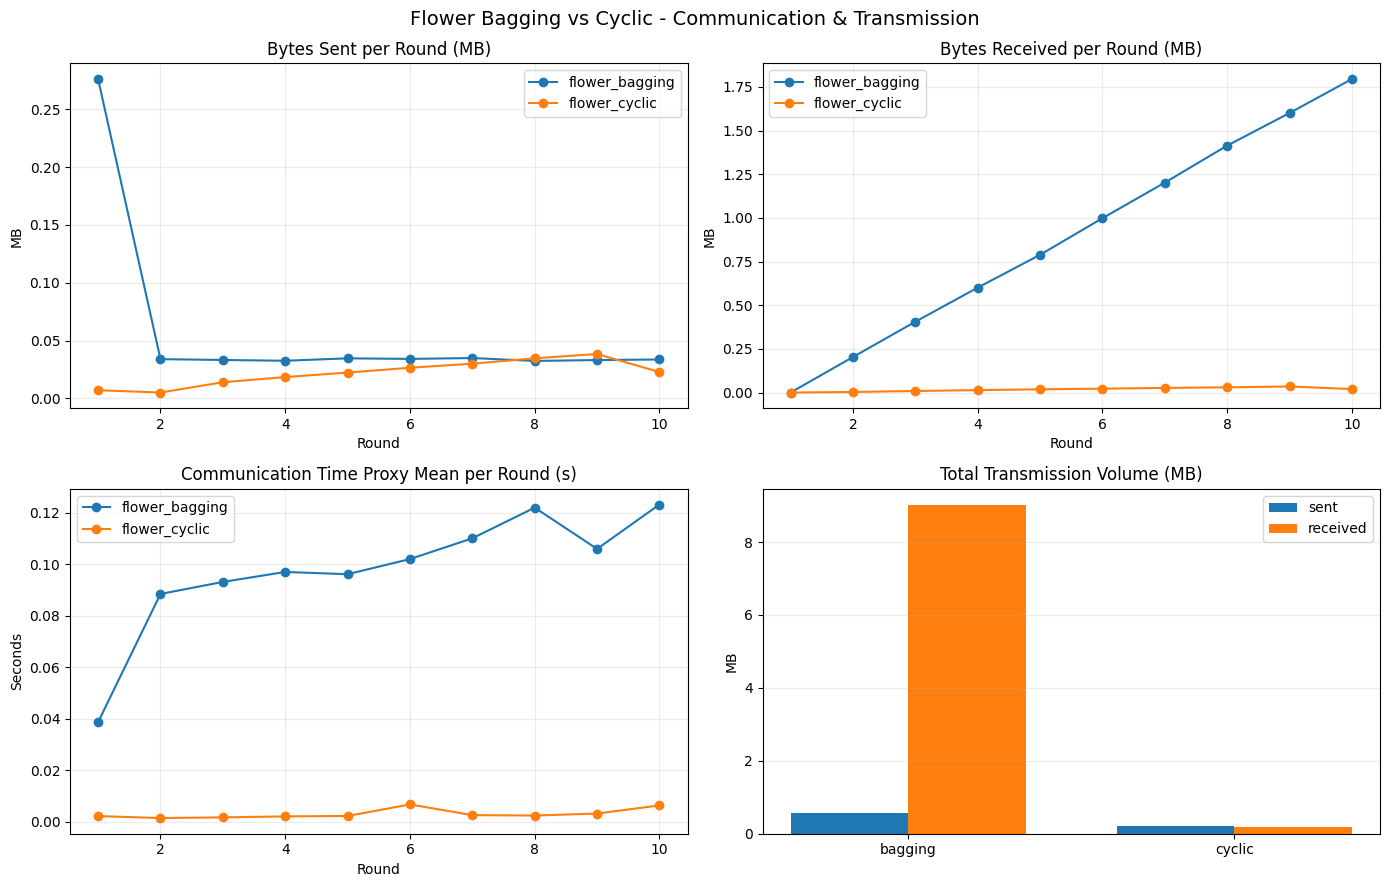

Plot salvato in: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark/results/plots/communication_bagging_vs_cyclic_notebook.png


In [8]:
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax1, ax2, ax3, ax4 = axes.flatten()

for approach, g in round_summary.groupby('approach'):
    ax1.plot(g['round'], g['bytes_sent_total'] / (1024 * 1024), marker='o', label=approach)
    ax2.plot(g['round'], g['bytes_received_total'] / (1024 * 1024), marker='o', label=approach)
    ax3.plot(g['round'], g['comm_time_mean'], marker='o', label=approach)

ax1.set_title('Bytes Sent per Round (MB)')
ax1.set_xlabel('Round')
ax1.set_ylabel('MB')
ax1.grid(alpha=0.25)

ax2.set_title('Bytes Received per Round (MB)')
ax2.set_xlabel('Round')
ax2.set_ylabel('MB')
ax2.grid(alpha=0.25)

ax3.set_title('Communication Time Proxy Mean per Round (s)')
ax3.set_xlabel('Round')
ax3.set_ylabel('Seconds')
ax3.grid(alpha=0.25)

x = range(len(approach_summary))
ax4.bar([i - 0.18 for i in x], approach_summary['bytes_sent_total'] / (1024 * 1024), width=0.36, label='sent')
ax4.bar([i + 0.18 for i in x], approach_summary['bytes_received_total'] / (1024 * 1024), width=0.36, label='received')
ax4.set_xticks(list(x), [a.replace('flower_', '') for a in approach_summary['approach']])
ax4.set_title('Total Transmission Volume (MB)')
ax4.set_ylabel('MB')
ax4.grid(axis='y', alpha=0.25)

for ax in (ax1, ax2, ax3):
    ax.legend()
ax4.legend()

fig.suptitle('Flower Bagging vs Cyclic - Communication & Transmission', fontsize=14, y=0.98)
fig.tight_layout()

out_plot = PLOTS_DIR / 'communication_bagging_vs_cyclic_notebook.png'
fig.savefig(out_plot, dpi=180)
plt.show()

print('Plot salvato in:', out_plot)

In [9]:
summaries_dir = STRUCTURED_DIR / 'summaries'
summaries_dir.mkdir(parents=True, exist_ok=True)

round_summary_file = summaries_dir / 'communication_round_summary.csv'
approach_summary_file = summaries_dir / 'communication_approach_summary.csv'
snapshot_json = summaries_dir / 'latest_comm_snapshot.json'

round_summary.to_csv(round_summary_file, index=False)
approach_summary.to_csv(approach_summary_file, index=False)
snapshot_json.write_text(
    json.dumps(
        {
            'round_summary_rows': len(round_summary),
            'approach_summary_rows': len(approach_summary),
            'approaches': sorted(approach_summary['approach'].tolist()),
        },
        indent=2,
    ),
    encoding='utf-8',
)

print('CSV round-level:', round_summary_file)
print('CSV approach-level:', approach_summary_file)
print('Snapshot JSON:', snapshot_json)

CSV round-level: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark/results/structured_metrics/summaries/communication_round_summary.csv
CSV approach-level: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark/results/structured_metrics/summaries/communication_approach_summary.csv
Snapshot JSON: /Users/annamettifogo/Desktop/polimi/necstlab/progetto_LS2/fl_benchmark/results/structured_metrics/summaries/latest_comm_snapshot.json
